### Importação de bibliotecas

In [4]:
import pandas as pd
import polars as pl
import pyarrow as pa
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import seaborn as sns
import os
import time

### Conversão de CSV em PARQUET

In [5]:
arquivo_csv = 'tracks_features.csv'
arquivo_parquet = 'tracks_features.csv.parquet'

# 1. scan_csv() apenas cria o plano (LazyFrame)
lazy_query = pl.scan_csv(arquivo_csv, separator=',', encoding='utf8-lossy')

# 2. sink_parquet() executa o plano em modo streaming
#    e salva o resultado direto no disco.
lazy_query.sink_parquet(arquivo_parquet)

print(f"Arquivo '{arquivo_csv}' convertido para '{arquivo_parquet}' com sucesso!")

Arquivo 'tracks_features.csv' convertido para 'tracks_features.csv.parquet' com sucesso!


### Obtenção inicial das informações do arquivo

In [6]:
dados=pd.read_parquet('tracks_features.csv.parquet')
dados=dados.dropna() #Para excluir valores nulos
display(dados.describe())
display(dados.head())

,track_number,disc_number,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,year
count,1.204025e+06,1.204025e+06,1.204025e+06,1.204025e+06,1.204025e+06,1.204025e+06,1.204025e+06,1.204025e+06,1.204025e+06,1.204025e+06,1.204025e+06,1.204025e+06,1.204025e+06,1.204025e+06,1.204025e+06,1.204025e+06
mean,7.656352e+00,1.055906e+00,4.930565e-01,5.095363e-01,5.194151e+00,-1.180870e+01,6.714595e-01,8.438219e-02,4.467511e-01,2.828605e-01,2.015994e-01,4.279866e-01,1.176344e+02,2.488399e+05,3.832494e+00,2.007328e+03
std,5.994977e+00,2.953752e-01,1.896694e-01,2.946839e-01,3.536731e+00,6.982132e+00,4.696827e-01,1.159914e-01,3.852014e-01,3.762844e-01,1.804591e-01,2.704846e-01,3.093705e+01,1.622104e+05,5.611826e-01,1.210117e+01
min,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-6.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+03,0.000000e+00,0.000000e+00
25%,3.000000e+00,1.000000e+00,3.560000e-01,2.520000e-01,2.000000e+00,-1.525400e+01,0.000000e+00,3.510000e-02,3.760000e-02,7.600000e-06,9.680000e-02,1.910000e-01,9.405400e+01,1.740900e+05,4.000000e+00,2.002000e+03
50%,7.000000e+00,1.000000e+00,5.010000e-01,5.240000e-01,5.000000e+00,-9.791000e+00,1.000000e+00,4.460000e-02,3.890000e-01,8.080000e-03,1.250000e-01,4.030000e-01,1.167260e+02,2.243390e+05,4.000000e+00,2.009000e+03
75%,1.000000e+01,1.000000e+00,6.330000e-01,7.660000e-01,8.000000e+00,-6.717000e+00,1.000000e+00,7.230000e-02,8.610000e-01,7.190000e-01,2.450000e-01,6.440000e-01,1.370460e+02,2.858400e+05,4.000000e+00,2.015000e+03
max,5.000000e+01,1.300000e+01,1.000000e+00,1.000000e+00,1.100000e+01,7.234000e+00,1.000000e+00,9.690000e-01,9.960000e-01,1.000000e+00,1.000000e+00,1.000000e+00,2.489340e+02,6.061090e+06,5.000000e+00,2.020000e+03


,id,name,album,album_id,artists,artist_ids,track_number,disc_number,explicit,danceability,...,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,year,release_date
0,7lmeHLHBe4nmXzuXc0HDjk,Testify,The Battle Of Los Angeles,2eia0myWFgoHuttJytCxgX,['Rage Against The Machine'],['2d0hyoQ5ynDBnkvAbJKORj'],1,1,False,0.470,...,0.0727,0.02610,0.000011,0.3560,0.503,117.906,210133,4.0,1999,1999-11-02
1,1wsRitfRRtWyEapl0q22o8,Guerrilla Radio,The Battle Of Los Angeles,2eia0myWFgoHuttJytCxgX,['Rage Against The Machine'],['2d0hyoQ5ynDBnkvAbJKORj'],2,1,True,0.599,...,0.1880,0.01290,0.000071,0.1550,0.489,103.680,206200,4.0,1999,1999-11-02
2,1hR0fIFK2qRG3f3RF70pb7,Calm Like a Bomb,The Battle Of Los Angeles,2eia0myWFgoHuttJytCxgX,['Rage Against The Machine'],['2d0hyoQ5ynDBnkvAbJKORj'],3,1,False,0.315,...,0.4830,0.02340,0.000002,0.1220,0.370,149.749,298893,4.0,1999,1999-11-02
3,2lbASgTSoDO7MTuLAXlTW0,Mic Check,The Battle Of Los Angeles,2eia0myWFgoHuttJytCxgX,['Rage Against The Machine'],['2d0hyoQ5ynDBnkvAbJKORj'],4,1,True,0.440,...,0.2370,0.16300,0.000004,0.1210,0.574,96.752,213640,4.0,1999,1999-11-02
4,1MQTmpYOZ6fcMQc56Hdo7T,Sleep Now In the Fire,The Battle Of Los Angeles,2eia0myWFgoHuttJytCxgX,['Rage Against The Machine'],['2d0hyoQ5ynDBnkvAbJKORj'],5,1,False,0.426,...,0.0701,0.00162,0.105000,0.0789,0.539,127.059,205600,4.0,1999,1999-11-02


### Criação de LazyFrame + conversão de ms em min

In [7]:
import polars as pl

spotify_bg = pl.scan_parquet("tracks_features.csv.parquet")

spotifybg = spotify_bg.with_columns(
    (pl.col("duration_ms") / 60000).alias("duration_min")
)


print(spotifybg.explain())

print("--- Executando (Collect) ---")
start_time = time.time()
df_resultado = spotifybg.collect()
end_time = time.time()

display(df_resultado)

 WITH_COLUMNS:
 [[(col("duration_ms")) / (60000)].alias("duration_min")] 
  Parquet SCAN [tracks_features.csv.parquet]
  PROJECT */24 COLUMNS
  ESTIMATED ROWS: 1204025
--- Executando (Collect) ---


id,name,album,album_id,artists,artist_ids,track_number,disc_number,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,year,release_date,duration_min
str,str,str,str,str,str,i64,i64,bool,f64,f64,i64,f64,i64,f64,f64,f64,f64,f64,f64,i64,f64,i64,str,f64
"""7lmeHLHBe4nmXzuXc0HDjk""","""Testify""","""The Battle Of Los Angeles""","""2eia0myWFgoHuttJytCxgX""","""['Rage Against The Machine']""","""['2d0hyoQ5ynDBnkvAbJKORj']""",1,1,false,0.47,0.978,7,-5.399,1,0.0727,0.0261,0.0000109,0.356,0.503,117.906,210133,4.0,1999,"""1999-11-02""",3.502217
"""1wsRitfRRtWyEapl0q22o8""","""Guerrilla Radio""","""The Battle Of Los Angeles""","""2eia0myWFgoHuttJytCxgX""","""['Rage Against The Machine']""","""['2d0hyoQ5ynDBnkvAbJKORj']""",2,1,true,0.599,0.957,11,-5.764,1,0.188,0.0129,0.0000706,0.155,0.489,103.68,206200,4.0,1999,"""1999-11-02""",3.436667
"""1hR0fIFK2qRG3f3RF70pb7""","""Calm Like a Bomb""","""The Battle Of Los Angeles""","""2eia0myWFgoHuttJytCxgX""","""['Rage Against The Machine']""","""['2d0hyoQ5ynDBnkvAbJKORj']""",3,1,false,0.315,0.97,7,-5.424,1,0.483,0.0234,0.000002,0.122,0.37,149.749,298893,4.0,1999,"""1999-11-02""",4.98155
"""2lbASgTSoDO7MTuLAXlTW0""","""Mic Check""","""The Battle Of Los Angeles""","""2eia0myWFgoHuttJytCxgX""","""['Rage Against The Machine']""","""['2d0hyoQ5ynDBnkvAbJKORj']""",4,1,true,0.44,0.967,11,-5.83,0,0.237,0.163,0.000004,0.121,0.574,96.752,213640,4.0,1999,"""1999-11-02""",3.560667
"""1MQTmpYOZ6fcMQc56Hdo7T""","""Sleep Now In the Fire""","""The Battle Of Los Angeles""","""2eia0myWFgoHuttJytCxgX""","""['Rage Against The Machine']""","""['2d0hyoQ5ynDBnkvAbJKORj']""",5,1,false,0.426,0.929,2,-6.729,1,0.0701,0.00162,0.105,0.0789,0.539,127.059,205600,4.0,1999,"""1999-11-02""",3.426667
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""0EsMifwUmMfJZxzoMPXJKZ""","""Gospel of Juke""","""Notch - EP""","""38O5Ys0W9PFS5K7dMb7yKb""","""['FVLCRVM']""","""['7AjItKsRnEYRSiBt2OxK1y']""",2,1,false,0.264,0.966,5,-6.97,0,0.0672,0.00935,0.00224,0.337,0.415,159.586,276213,4.0,2014,"""2014-01-09""",4.60355
"""2WSc2TB1CSJgGE0PEzVeiu""","""Prism Visions""","""Notch - EP""","""38O5Ys0W9PFS5K7dMb7yKb""","""['FVLCRVM']""","""['7AjItKsRnEYRSiBt2OxK1y']""",3,1,false,0.796,0.701,11,-6.602,0,0.0883,0.104,0.644,0.0749,0.781,121.98,363179,4.0,2014,"""2014-01-09""",6.052983
"""6iProIgUe3ETpO6UT0v5Hg""","""Tokyo 360""","""Notch - EP""","""38O5Ys0W9PFS5K7dMb7yKb""","""['FVLCRVM']""","""['7AjItKsRnEYRSiBt2OxK1y']""",4,1,false,0.785,0.796,9,-5.96,0,0.0564,0.0304,0.918,0.0664,0.467,121.996,385335,4.0,2014,"""2014-01-09""",6.42225


### Classificação de danceability

In [8]:
analise_danceability = (
    spotifybg
    .with_columns(
        pl.when(pl.col("danceability") >= 0.7)
          .then(pl.lit("alta"))
        .when(pl.col("danceability") >= 0.4)
          .then(pl.lit("media"))
        .otherwise(pl.lit("baixa"))
        .alias("danceability_class")
    )
    .group_by("danceability_class")
    .agg([
        pl.col("duration_min").mean().alias("duracao_media_min"),
        pl.len().alias("qtd_faixas")
    ])
)
analise_danceability.collect()

danceability_class,duracao_media_min,qtd_faixas
str,f64,u32
"""media""",3.953447,643502
"""alta""",3.812034,178869
"""baixa""",4.631378,381654


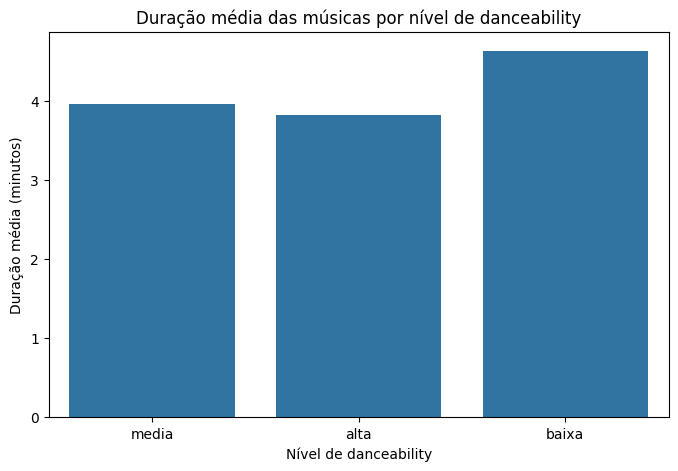

In [9]:
df_spotify = analise_danceability.collect().to_pandas()


plt.figure(figsize=(8, 5))

sns.barplot(
    data=df_spotify,
    x="danceability_class",
    y="duracao_media_min"
)

plt.title("Duração média das músicas por nível de danceability")
plt.xlabel("Nível de danceability")
plt.ylabel("Duração média (minutos)")

plt.show()


Músicas mais dançantes são mais curtas

### Quantidade de faixas por danceability

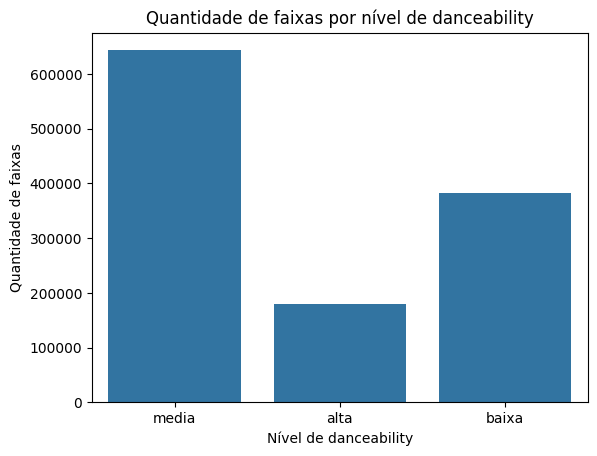

In [10]:
sns.barplot(
    data=df_spotify,
    x="danceability_class",
    y="qtd_faixas"
)
plt.title("Quantidade de faixas por nível de danceability")
plt.xlabel("Nível de danceability")
plt.ylabel("Quantidade de faixas")
plt.show()


### Médias dos atributos por ano

In [11]:
yearly_stats = (
    spotifybg
    .group_by("year")
    .agg([
        pl.col("danceability").mean().alias("avg_danceability"),
        pl.col("energy").mean().alias("avg_energy"),
        pl.col("valence").mean().alias("avg_valence"),
        pl.col("tempo").mean().alias("avg_tempo")
    ])
    .sort("year")
)

yearly_stats.collect()

year,avg_danceability,avg_energy,avg_valence,avg_tempo
i64,f64,f64,f64,f64
0,0.7655,0.5016,0.6546,115.981
1900,0.483857,0.282193,0.422157,128.728571
1908,0.604105,0.473695,0.657,131.799737
1909,0.61756,0.4848,0.82388,111.96864
1917,0.506942,0.253687,0.480892,118.500192
…,…,…,…,…
2016,0.494651,0.54702,0.404568,118.940693
2017,0.49571,0.545366,0.394594,118.728206
2018,0.517009,0.569536,0.404441,119.539635


### Quartiles da dançabilidade

In [12]:
quartiles = spotifybg.select([
    pl.col("danceability").quantile(0.25).alias("Q1_danceability"),
    pl.col("danceability").quantile(0.50).alias("Q2_danceability"),
    pl.col("danceability").quantile(0.75).alias("Q3_danceability"),
])

quartiles.collect()

Q1_danceability,Q2_danceability,Q3_danceability
f64,f64,f64
0.356,0.501,0.633


### Detecção de outliers

In [13]:
q = spotifybg.select([
    pl.col("tempo").quantile(0.25).alias("q1"),
    pl.col("tempo").quantile(0.75).alias("q3")
]).collect()

q1 = q["q1"][0]
q3 = q["q3"][0]
iqr = q3 - q1

outliers = spotifybg.filter(
    (pl.col("tempo") < q1 - 1.5 * iqr) |
    (pl.col("tempo") > q3 + 1.5 * iqr)
)
outliers.select(["name", "artists", "tempo", "year"]).collect().head()


name,artists,tempo,year
str,str,f64,i64
"""Love Hate""","""['Bride']""",201.604,1997
"""Got Into My Head & Stole My He…","""['Nodesha']""",207.329,2003
"""Can't Lose What You Never Had""","""['Westlife']""",204.312,1999
"""Be Careful with a Fool""","""['Johnny Winter']""",206.991,1973
"""Grandpa (Tell Me 'Bout The Goo…","""['The Judds']""",201.672,1988


### Correlação

In [ ]:
corr_metrics = spotifybg.select([
    pl.corr("energy", "danceability").alias("corr_energy_danceability"),
    pl.corr("energy", "loudness").alias("corr_energy_loudness"),
    pl.corr("danceability", "valence").alias("corr_danceability_valence"),
    pl.corr("tempo", "danceability").alias("corr_tempo_danceability")
])
corr_metrics.collect()


corr_energy_danceability,corr_energy_loudness,corr_danceability_valence,corr_tempo_danceability
f64,f64,f64,f64
0.283016,0.817934,0.563436,0.06059


### Duração média das músicas por ano

In [ ]:
duration_by_year = (
    spotifybg
    .group_by("year")
    .agg(
        pl.col("duration_min").mean().alias("avg_duration_min")
    )
    .sort("year")
)

df_duration = duration_by_year.collect()
df_duration


year,avg_duration_min
i64,f64
0,2.78894
1900,8.334367
1908,3.770058
1909,2.922657
1917,4.328397
…,…
2016,4.233196
2017,4.217801
2018,4.115948


### Relação de duração X ano

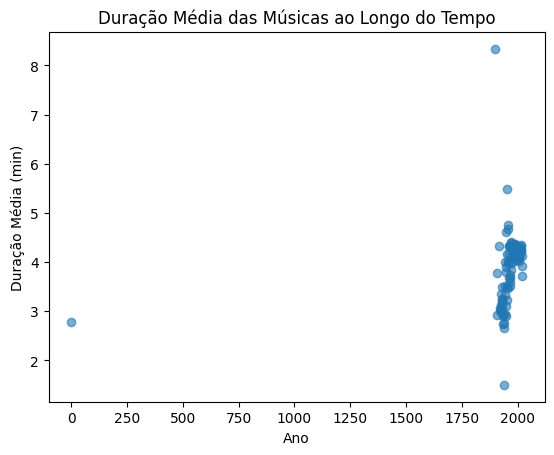

In [ ]:
import matplotlib.pyplot as plt

x = df_duration["year"].to_numpy()
y = df_duration["avg_duration_min"].to_numpy()

plt.scatter(x, y, alpha=0.6)
plt.xlabel("Ano")
plt.ylabel("Duração Média (min)")
plt.title("Duração Média das Músicas ao Longo do Tempo")
plt.show()


In [ ]:
duracao_por_ano = (
    spotifybg
    .with_columns(
        (pl.col("duration_ms") / 60000).alias("duration_min")
    )
    .group_by("year")
    .agg(
        pl.col("duration_min").mean().alias("duracao_media_min")
    )
    .sort("year")
)
df_spotify = duracao_por_ano.collect().to_pandas()


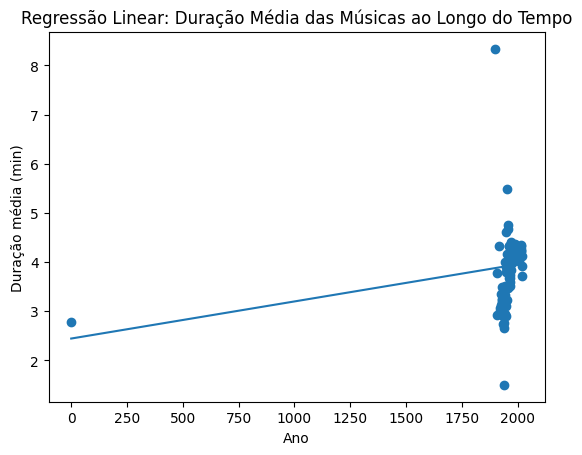

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

x = df_spotify["year"]
y = df_spotify["duracao_media_min"]

coef = np.polyfit(x, y, 1)
poly = np.poly1d(coef)

plt.figure()
plt.scatter(x, y)
plt.plot(x, poly(x))
plt.xlabel("Ano")
plt.ylabel("Duração média (min)")
plt.title("Regressão Linear: Duração Média das Músicas ao Longo do Tempo")
plt.show()


### Exportação para CSV

In [ ]:

spotifybg = spotify_bg.with_columns(
    (pl.col("duration_ms") / 60000).alias("duration_min")
)

df_duracao = spotifybg.select("duration_min").collect()

q1 = df_duracao.select(pl.col("duration_min").quantile(0.25)).item()
q3 = df_duracao.select(pl.col("duration_min").quantile(0.75)).item()

print(f"Músicas abaixo de {q1:.2f} min → Curta duração")
print(f"Músicas acima de {q3:.2f} min → Longa duração")

spotify_extremos = spotifybg.with_columns(
    pl.when(pl.col("duration_min") > q3)
      .then(pl.lit("Longa Duração"))
    .when(pl.col("duration_min") < q1)
      .then(pl.lit("Curta Duração"))
    .otherwise(pl.lit("Duração Média"))
    .alias("classe_duracao")
).filter(
    pl.col("classe_duracao").is_in(["Curta Duração", "Longa Duração"])
)

spotify_reduzido = spotify_extremos.select([
    "name",
    "artists",
    "energy",
    "danceability",
    "valence",
    "tempo",
    "loudness",
    "acousticness",
    "speechiness",
    "instrumentalness",
    "duration_min",
    "year",
    "release_date",
    "classe_duracao"
])
spotify_reduzido.collect().write_csv(
    "spotify_reduzido.csv"
)


Músicas abaixo de 2.90 min → Curta duração
Músicas acima de 4.76 min → Longa duração
